# CMIP Projections

The 5 parameter sets calculkated in Calibration_HBV.ipynb will be used for a validation period, in which the log NSE will be calculated, a mean will be calculated and total low flow days during the navigation season.

The structure of this notebook is as follows:

### 1. Startup & Imports
### 2. Model setup
### 3. Lowflow setup
### 4. Running model
### 5. Lowflow data visualisation
### 6. Forcing data comparison & visualisation
### 7. Algorithm checker (break up, freeze up dates)

## 1. Startup & Imports

In [3]:
# Imports

# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.interpolate import interp1d
from scipy.stats import linregress

# Niceties
from rich import print

In [4]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [3]:
# Defining things

basin_size = 132572
q_critical = 500

start_year = 2025
end_year = 2050

In [4]:
# Define only future scenarios
scenarios = ["ssp126", "ssp245", "ssp370"]

# Redefine scenarios to include historical
scenarios_new = ["historical", "ssp126", "ssp245", "ssp370"]

# Attach colours to scenarios to make plotting easier 
colours = {"historical": "tab:blue", "ssp126": "green", "ssp245": "orange", "ssp370": "red"}

# Define periods
periods = [[2025, 2050, 2075],
           [2050, 2075, 2099]]

hist_periods = ([1989], [2014]) 

In [5]:
# Create pathways

def forcing_path_cmip(scenario, start_year, end_year):
    
    forcing_path = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / scenario / f"CMIP6-{start_year}-{end_year}"
    
    return forcing_path

shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

In [6]:
# Adjust time period

validation_start = f"{start_year}-01-01T00:00:00Z"
validation_end = f"{end_year}-12-31T00:00:00Z"

# Define time period
validation_start_date = pd.to_datetime(validation_start.replace("Z", ""))
validation_end_date = pd.to_datetime(validation_end.replace("Z", ""))

# Skip 1 year for filling storages
evaluation_start = pd.to_datetime(f"{validation_start_date.year + 1}-01-01")

In [7]:
# Load in observed discharge data

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

## 2. Model setup

For running the model, the following steps are taken:

##### 2.1 Load parameter sets & initial storages
##### 2.2 Model configuration
##### 2.3 Model setup run

### 2.1 Load parameter sets & initial storages

In [8]:
# Define parameter ensemble

par_ensemble = [
    [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606],
    [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504],
    [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857],
    [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392],
   [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]]


par_names = ["Imax",         # Maximum interception storage
               "Ce",         # Evaporation correction factor
               "Sumax",      # Maximum soil moisture storage
               "Beta",       # Soil runoff parameter
               "Pmax",       # Maximum percolation rate
               "Tlag",       # Time lag
               "Kf",         # Fast reservoir recession coefficient
               "Ks",         # Slow reservoir recession coefficient
               "FM"]          # Snowmelt factor

In [9]:
# Define initial storages

#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

### 2.2 Model configuration

In [10]:
# Model setup create function

def run_hbv(parameters, initial_storages, forcing):

    # Creating model object
    model = ewatercycle.models.HBV(forcing=forcing)

    # Creating config file
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storages=initial_storages,
        cfg_dir=hbv_config)

    # Initialising model
    model.initialize(config_file)

    # Define & update outputs
    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Convert mm/day to m3/s
    model_output_mmday = pd.Series(
        data=Q_m,
        index=time,
        name="Modelled discharge")

    model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

    return model_output_m3s

### 2.3 Model setup run

In [11]:
# Model running create function

def run_hbv_ensemble(par_ensemble, initial_storages, forcing):

    # Define amount of parameter sets
    N = len(par_ensemble)
    
    # Create dataframe to append data to & add column for observed data
    ensemble_data = pd.DataFrame()

    for i in range(N):

        print(f"Running parameter set {i+1}/{N}")

        # Run HBV model for the parameter sets 
        simulated = run_hbv(
            parameters=par_ensemble[i],
            initial_storages=initial_storages,
            forcing=forcing)

        # Filter data by day only, not by day & time to prevent alignment issues
        simulated_daily = simulated

        simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
        simulated_daily.name = f"Set {i+1}"
         
        # Append new column for every parameter set results
        ensemble_data[f"Set {i+1}"] = simulated

    # Add mean of all sets
    ensemble_data["Mean"] = ensemble_data.mean(axis=1)

    return ensemble_data

## 3. Lowflow setup

Before running the model, the way lowflows are counted must be defined. this is so these functions can be called for every model run under every parameter set, scenario type and time period. The following steps are taken:

##### 3.1 Lowflow counter for the future
##### 3.2 Lowflow counter for observed data

### 3.1 Lowflow counter for the future 

In [12]:
def lowflow_counter_future(ensemble_data, start_date, end_date):

    lowflow_days = []

    years = list(range(start_date.year, end_date.year + 1))

    for i in range(len(years)):

        year = years[i]

        year_start = pd.to_datetime(f"{year}-05-18")
        year_end = pd.to_datetime(f"{year}-10-17")

        year_data = ensemble_data[
            (ensemble_data.index >= year_start) &
            (ensemble_data.index <= year_end)]

        modelled_lowflow_days = []

        # Count parameter set low-flow days
        for j in range(len(par_ensemble)):

            set_lowflow_days = 0

            for k in range(len(year_data)):

                set_q = year_data.iloc[k][f"Set {j+1}"]

                if set_q < q_critical:
                    set_lowflow_days += 1

            modelled_lowflow_days.append(set_lowflow_days)

        setavg_lowflow_days = np.mean(modelled_lowflow_days)

        lowflow_days.append({
            "year": year,
            "set_1": modelled_lowflow_days[0],
            "set_2": modelled_lowflow_days[1],
            "set_3": modelled_lowflow_days[2],
            "set_4": modelled_lowflow_days[3],
            "set_5": modelled_lowflow_days[4],
            "set_avg": np.round(setavg_lowflow_days)})

    lowflow_days = pd.DataFrame(lowflow_days)

    return lowflow_days

### 3.2 Lowflow counter for observed data

In [1]:
def observed_lowflow_days(start_year=2000, end_year=2025):

    observed_lowflows = []

    for year in range(start_year, end_year + 1):

        season_start = pd.to_datetime(f"{year}-05-18")
        season_end = pd.to_datetime(f"{year}-10-17")

        year_data = q_obs[
            (q_obs["Date"] >= season_start) &
            (q_obs["Date"] <= season_end)]

        lowflow_days = (year_data["discharge_m3s"] < q_critical).sum()

        observed_lowflows.append({
            "year": year,
            "observed_lowflow_days": lowflow_days})

    observed_lowflows = pd.DataFrame(observed_lowflows)

    observed_average = round(observed_lowflows["observed_lowflow_days"].mean())
    observed_total = observed_lowflows["observed_lowflow_days"].sum()

    print("Observed average low-flow days/year:", observed_average)
    print("Observed total low-flow days:", observed_total)

    return observed_lowflows, observed_average

In [2]:
observed_lowflows, observed_avg = observed_lowflow_days(start_year=2000, end_year=2025)

NameError: name 'pd' is not defined

## 4. Running model

The previous functions in 2. and 3. will be used to run the model for every possible scenario and calculate the lowflows. The following steps are taken:

##### 4.1 Function for running one projection
##### 4.2 Running for every projection and store the data 

### 4.1 Function for running one projection

In [15]:
def run_one_projection(scenario, start_year, end_year):

    print(f"Running {scenario}, {start_year}-{end_year}")

    # Find forcing path for scenario and period
    forcing_path = forcing_path_cmip(
        scenario=scenario,
        start_year=start_year,
        end_year=end_year)

    # Generate forcing
    CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path)

    # Run ensemble 
    ensemble_data = run_hbv_ensemble(
        par_ensemble=par_ensemble,
        initial_storages=s_0,
        forcing=CMIP_forcing)

    # Calculate lowflows
    lowflow_table = lowflow_counter_future(
        ensemble_data=ensemble_data,
        start_date=pd.to_datetime(f"{start_year}-01-01"),
        end_date=pd.to_datetime(f"{end_year}-12-31"))

    return ensemble_data, lowflow_table

### 4.2 Running for every projection and store the data 

In [16]:
projection_data = {}
use_periods = []

for scenario in scenarios:
    
    for i in range(len(periods[0])):

        # Define start year
        start_year = periods[0][i]
        end_year = periods[1][i]

        # Define key where data will be saved
        key = f"{scenario}_{start_year}_{end_year}"

        # Run HBV
        ensemble_data, lowflow_table = run_one_projection(scenario=scenario, start_year=start_year, end_year=end_year)

        # Save data in projection_data
        projection_data[key] = {
            "ensemble": ensemble_data,
            "lowflow": lowflow_table}

Running ssp126, 2025-2050

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

...

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

Running parameter set 5/5

## 5. Lowflow data visualisation

All the results have been ran and calculated in previous chapters. Here results are presented. First a table will be created showing lowflow days for 25 year periods from 2000-2100 under various climate scenarios. Second, a CDF distribution will be shown:

##### 5.1 Lowflow table
##### 5.2 Lowflow plot
##### 5.3 CDF
##### 5.4 Quantiles

### 5.1 Lowflow table

In [17]:
def create_lowflow_summary_table(projection_data, scenarios, periods):

    rows = []

    for scenario in scenarios:

        # Define table rows 
        row = {"scenario": scenario}

        # Put observed data in table
        row["Observed 2000-2025"] = round(observed_avg)

        for i in range(len(periods[0])):

            # Define period
            start_year = periods[0][i]
            end_year = periods[1][i]

            # Take data for relevant scenario and period 
            key = f"{scenario}_{start_year}_{end_year}"
            period_name = f"{start_year}-{end_year}"

            # Extract data from projection_key
            lowflow_table = projection_data[key]["lowflow"]

            # Put extracted data in new table
            row[period_name] = round(lowflow_table["set_avg"].mean())

        rows.append(row)

    return pd.DataFrame(rows)

In [18]:
summary_table = create_lowflow_summary_table(
    projection_data=projection_data,
    scenarios=scenarios,
    periods=periods)

summary_table

,scenario,Observed 2000-2025,2025-2050,2050-2075,2075-2099
0,ssp126,27,36,38,35
1,ssp245,27,40,38,31
2,ssp370,27,34,45,49


### 5.2 Lowflow plot 

In [19]:
def plot_annual_lowflow_days(projection_data, scenarios, periods, observed_lowflows):

    plt.figure(figsize=(9, 5))

    # Plot observed historical low flow days
    observed_data = observed_lowflows.copy()

    plt.scatter(observed_data["year"], observed_data["observed_lowflow_days"], color=colours["historical"], alpha=0.5, label="historical")

    # Historical trendline for 2000-2025
    x = observed_data["year"].values
    y = observed_data["observed_lowflow_days"].values

    slope, intercept = np.polyfit(x, y, 1)
    trend = slope * x + intercept

    plt.plot(x, trend, linestyle="--", color=colours["historical"])

    # Plot future scenarios
    for scenario in scenarios:

        all_years = []
        all_lowflows = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"

            lowflow_table = projection_data[key]["lowflow"]

            years = lowflow_table["year"].values
            lowflows = lowflow_table["set_avg"].values

            all_years.extend(years)
            all_lowflows.extend(lowflows)

        scenario_data = pd.DataFrame({
            "year": all_years,
            "set_avg": all_lowflows})

        scenario_data = scenario_data.sort_values("year")


        # Plot yearly low flow days
        plt.scatter(scenario_data["year"], scenario_data["set_avg"], color=colours[scenario], alpha=0.30, label=scenario)

        # Plot trendline for 2025-2099
        x = scenario_data["year"].values
        y = scenario_data["set_avg"].values

        slope, intercept = np.polyfit(x, y, 1)
        trend = slope * x + intercept

        plt.plot(x, trend, linestyle="--", color=colours[scenario])

    plt.xlabel("Year")
    plt.ylabel("Annual low flow days")
    plt.title("Annual low flow days in LAR basin by climate scenario")
    plt.grid(True)
    plt.legend()
    plt.show()

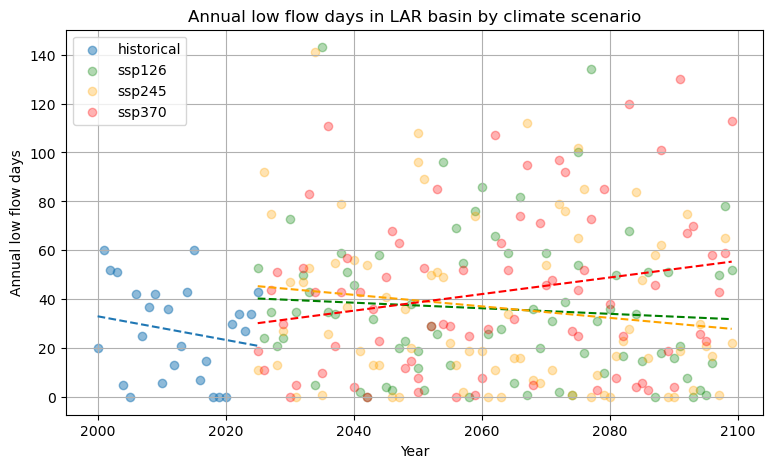

In [20]:
plot_annual_lowflow_days(
    projection_data=projection_data,
    scenarios=scenarios,
    periods=periods,
    observed_lowflows=observed_lowflows)

### Slope significance

In [21]:
# Calculate p values to determine statistical significance

def slope_significance(projection_data, observed_lowflows):
    results = []

    # Historical observed period
    x = observed_lowflows["year"].values
    y = observed_lowflows["observed_lowflow_days"].values

    reg = linregress(x, y)

    results.append({
        "scenario": "historical",
        "p_value": reg.pvalue})

    # Future scenarios
    for scenario in scenarios:
        all_years = []
        all_lowflows = []

        for i in range(len(periods[0])):
            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"
            lowflow_table = projection_data[key]["lowflow"]

            all_years.extend(lowflow_table["year"].values)
            all_lowflows.extend(lowflow_table["set_avg"].values)

        reg = linregress(all_years, all_lowflows)

        results.append({
            "scenario": scenario,
            "p_value": reg.pvalue})

    return pd.DataFrame(results)

In [22]:
slope_results = slope_significance(projection_data=projection_data, observed_lowflows=observed_lowflows)

slope_results

,scenario,p_value
0,historical,0.349174
1,ssp126,0.483318
2,ssp245,0.188232
3,ssp370,0.053621


### 5.3 CDF 

In [23]:
def plot_cdf(projection_data, scenarios, periods):

    plt.figure(figsize=(8, 5))

    # Observed CDF
    observed_values = np.sort(observed_lowflows["observed_lowflow_days"].values)
    observed_cdf = np.arange(1, len(observed_values) + 1) / len(observed_values)

    # plt.plot(observed_values,observed_cdf,marker="o",label="Observed 2000-2025")
    plt.plot(observed_cdf, observed_values, marker="o", label="Observed 2000-2025", color=colours["historical"])

    # Scenario CDFs
    for scenario in scenarios:

        all_lowflows = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"

            lowflow_table = projection_data[key]["lowflow"]

            all_lowflows.extend(lowflow_table["set_avg"].values)

        values = np.sort(all_lowflows)
        cdf = np.arange(1, len(values) + 1) / len(values)

        plt.plot(cdf,values,marker="o",label=scenario, color=colours[scenario])

    plt.ylabel("Annual low flow days")
    plt.xlabel("Cumulative probability")
    plt.title("CDF of annual low flow days")
    plt.grid(True)
    plt.legend()
    plt.show()

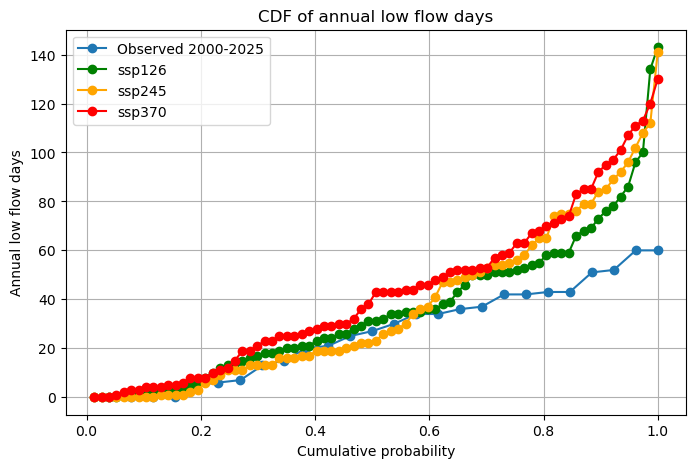

In [24]:
plot_cdf(
    projection_data=projection_data,
    scenarios=scenarios,
    periods=periods)

### 5.4 Quantiles

In [25]:
def lowflow_quantile_table(lowflow_results, scenarios, periods):

    rows = []

    for scenario in scenarios:

        all_lowflows = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"
            
            lowflow_table = lowflow_results[key]["lowflow"]

            all_lowflows.extend(lowflow_table["set_avg"].values)

        values = pd.Series(all_lowflows)

        # Append table and define quantiles 
        rows.append({
            "scenario": scenario,
            "mean": round(values.mean(), 1),
            "median": values.median(),
            "p50": values.quantile(0.5),
            "p75": values.quantile(0.75),
            "p90": values.quantile(0.90),
            "max": values.max()})

    return pd.DataFrame(rows)

In [26]:
lowflow_quantile_table(projection_data, scenarios, periods)

,scenario,mean,median,p50,p75,p90,max
0,ssp126,36.1,31.0,31.0,52.0,74.2,143.0
1,ssp245,36.6,23.0,23.0,56.0,84.4,141.0
2,ssp370,42.8,43.0,43.0,63.0,93.2,130.0


# 6. Forcing data comparison & visualisation

Here the forcing data will be analysed. First the forcing files will be loaded in and merged for each scenario. Then, units will be converted. Finally, yearly and period averages will be calculated and saved in lists. This will be used in 6.2 and 6.3 for visualisation.

##### 6.1 Loading and preparing forcing data
##### 6.2 Period forcing avg table
##### 6.3 Yearly forcing avg graph

### 6.3 Loading and preparing forcing data

All forcing data will be stored in forcing_data[scenario][var_name]

In [27]:
var_names = {"evspsblpot", "pr", "rsds", "tas"}

forcing_data = {}
annual_avg = []
period_avg = []

for scenario in scenarios:

    forcing_data[scenario] = {}

    for var_name in var_names:

        merged_data_list = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            # Define file path
            forcing_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / scenario / f"CMIP6-{start_year}-{end_year}" / f"combined_CMIP6_{start_year}_{end_year}_{var_name}.nc"
            
            # Load file as dataset
            ds = xr.open_dataset(forcing_file)

            # Load file as array
            da = ds[var_name]

            # Convert to series 
            series = pd.Series(data=da.values.squeeze(),index=pd.to_datetime(da["time"].values).normalize(),name=var_name)

            # Convert pr and evap from km^2/s to mm^2/day
            if var_name in ["pr", "evspsblpot"]:
                series = series * 86400
                annual = series.groupby(series.index.year).sum()

            # Convert temp from Kelvin to Celcius
            elif var_name == "tas":
                series = series - 273.15
                annual = series.groupby(series.index.year).mean()

            elif var_name == "rsds":
                annual = series.groupby(series.index.year).mean()

            # Save for merged time series
            merged_data_list.append(series)

            # Save annual values
            for year, annual_value in annual.items():

                annual_avg.append({
                    "scenario": scenario,
                    "period": f"{start_year}-{end_year}",
                    "year": year,
                    "variable": var_name,
                    "value": annual_value})

            # Save 25 year average
            period_avg.append({
                "scenario": scenario,
                "period": f"{start_year}-{end_year}",
                "variable": var_name,
                "value": annual.mean()})

        # Merge periods into one 2025–2099 series
        merged_data = pd.concat(merged_data_list)
        merged_data = merged_data[~merged_data.index.duplicated(keep="first")]
        merged_data = merged_data.sort_index()

        forcing_data[scenario][var_name] = merged_data

# Create summary table for annual avg values
annual_table = pd.DataFrame(annual_avg)

# Create summary table for period avg values
period_table = pd.DataFrame(period_avg).pivot_table(index=["scenario", "period"],columns="variable",values="value")

In [28]:
# Prepare historical data

def load_hist(start_year, end_year):

    forcing_data_hist = {}
    scenario = "historical"
    forcing_data_hist[scenario] = {}
    annual_avg = []

    for var_name in var_names:

        merged_data_list = []
    
        forcing_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / scenario / f"CMIP6-{start_year}-{end_year}" / f"combined_CMIP6_{start_year}_{end_year}_{var_name}.nc"

        # Load file as dataset
        ds = xr.open_dataset(forcing_file)

        # Load file as array
        da = ds[var_name]

        # Convert to series 
        series = pd.Series(data=da.values.squeeze(),index=pd.to_datetime(da["time"].values).normalize(),name=var_name)

        # Convert pr and evap from km^2/s to mm^2/day
        if var_name in ["pr", "evspsblpot"]:
            series = series * 86400
            annual = series.groupby(series.index.year).sum()

        # Convert temp from Kelvin to Celcius
        elif var_name == "tas":
            series = series - 273.15
            annual = series.groupby(series.index.year).mean()

        elif var_name == "rsds":
            annual = series.groupby(series.index.year).mean()

        # Save for merged time series
        merged_data_list.append(series)

        # Save annual values
        for year, annual_value in annual.items():

            annual_avg.append({
                "scenario": scenario,
                "period": f"{start_year}-{end_year}",
                "year": year,
                "variable": var_name,
                "value": annual_value})

        # Merge period into one series
        merged_data = pd.concat(merged_data_list)
        merged_data = merged_data[~merged_data.index.duplicated(keep="first")]
        merged_data = merged_data.sort_index()

        forcing_data_hist[scenario][var_name] = merged_data
            
    annual_hist_table = pd.DataFrame(annual_avg)
    
    return annual_hist_table, forcing_data_hist

In [29]:
annual_hist_table,forcing_data_hist = load_hist(start_year=1989,end_year=2014)

annual_hist_table.head()

,scenario,period,year,variable,value
0,historical,1989-2014,1989,tas,2.562430
1,historical,1989-2014,1990,tas,1.319359
2,historical,1989-2014,1991,tas,1.052132
3,historical,1989-2014,1992,tas,0.776736
4,historical,1989-2014,1993,tas,1.499663


In [30]:
# Merge forcing data (useful for freeze up calculation)

forcing_data_all = forcing_data.copy()

forcing_data_all["historical"] = forcing_data_hist["historical"]

### 6.2 Period forcing avg table

In [31]:
def create_period_forcing_table(annual_table):

    period_forcing_table = (annual_table.groupby(["scenario", "period", "variable"])["value"].mean().reset_index())

    period_forcing_table = period_forcing_table.pivot_table(index=["scenario", "period"], columns="variable", values="value")

    return period_forcing_table

In [32]:
period_forcing_table = round(create_period_forcing_table(annual_table), 1)

period_forcing_table

variable            evspsblpot     pr   rsds  tas
scenario period                                  
ssp126   2025-2050       621.1  633.9  138.5  2.5
         2050-2075       625.8  630.1  138.7  3.0
         2075-2099       621.5  645.3  138.2  2.7
ssp245   2025-2050       628.0  623.0  139.5  2.7
         2050-2075       632.7  637.3  138.3  3.6
         2075-2099       635.6  659.8  137.8  3.6
ssp370   2025-2050       623.4  640.5  138.5  2.7
         2050-2075       636.3  650.3  136.7  4.4
         2075-2099       656.9  645.7  136.6  5.4

### 6.3 Yearly forcing avg graph

In [33]:
def plot_annual_forcing_variable(annual_forcing_table, var_name):

    # Combine historical and scenarios
    annual_forcing_table_all = pd.concat([annual_hist_table, annual_forcing_table],ignore_index=True)
    data = annual_forcing_table_all[annual_forcing_table_all["variable"] == var_name]
    
    plt.figure(figsize=(9, 5))
    
    # Loop through scenarios
    for scenario in scenarios_new:

        # Extract one scenario and colour 
        scenario_data = data[data["scenario"] == scenario]
        colour = colours[scenario]

        # Plot historical 
        if scenario == "historical":
            
            # Plot yearly average 
            plt.plot(scenario_data["year"], scenario_data["value"], color=colour, linewidth=0.3, label=scenario)

            x = scenario_data["year"].values
            y = scenario_data["value"].values

            # Polyfit method for making trendline function
            slope, intercept = np.polyfit(x, y, 1)
            trend = slope * x + intercept

            # Plot trendline
            plt.plot(x,trend,linestyle="--",color=colour)

        # Plot other scenarios
        else:

            # Plot yearly average
            plt.plot(scenario_data["year"], scenario_data["value"], alpha=0.3, color=colour, label=scenario)

        # Look at each 25 year period
        for i in range(len(periods[0])):

            # Define period range
            start_year = periods[0][i]
            end_year = periods[1][i]

            # Adjust data to fit period range
            period_data = scenario_data[
            (scenario_data["year"] >= start_year) & 
            (scenario_data["year"] <= end_year)]

            # Plot trend line over each 25 year period
            if len(period_data) > 1:

                x = period_data["year"].values
                y = period_data["value"].values

                # Polyfit method for making trendline function
                slope, intercept = np.polyfit(x, y, 1)
                trend = slope * x + intercept

                # Plot trendline
                plt.plot(x,trend,linestyle="--",color=colour)

    # Define titles and labels based on var_name
    if var_name == "pr":
        ylabel = "Annual precipitation (mm/year)"
        title = "Annual precipitation in LAR basin by climate scenario"

    elif var_name == "evspsblpot":
        ylabel = "Annual potential evaporation (mm/year)"
        title = "Annual potential evaporation in LAR basin by climate scenario"

    elif var_name == "tas":
        ylabel = "Annual mean temperature increase (°C)"
        title = "Annual mean temperature in LAR basin by climate scenario"

    elif var_name == "rsds":
        ylabel = "Annual mean shortwave radiation (W/m²)"
        title = "Annual mean shortwave radiation in LAR basin by climate scenario"

    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

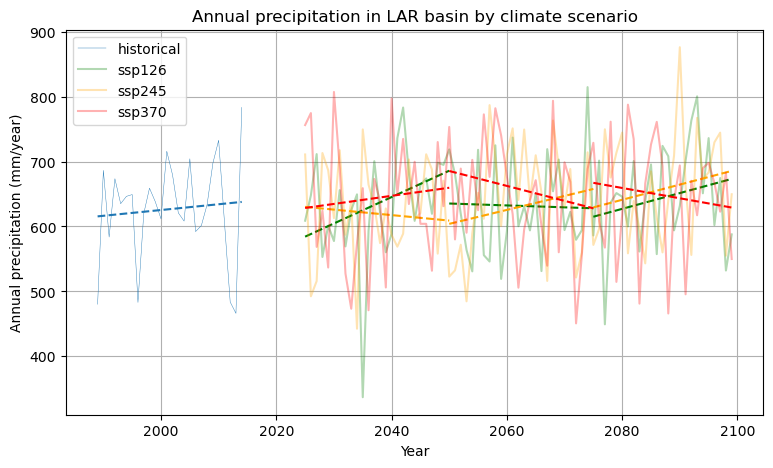

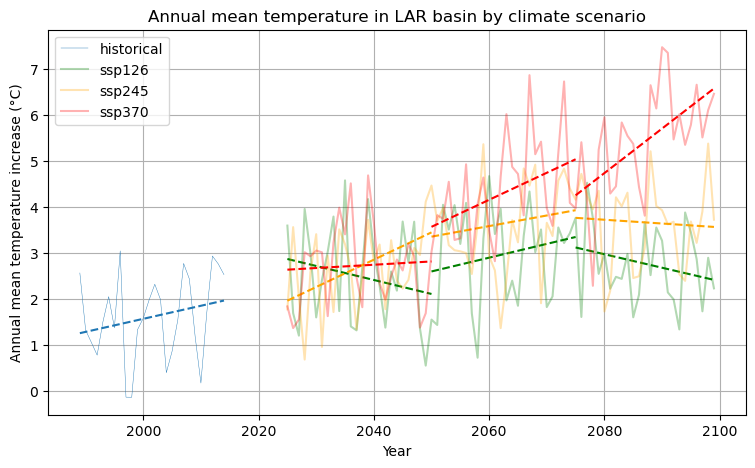

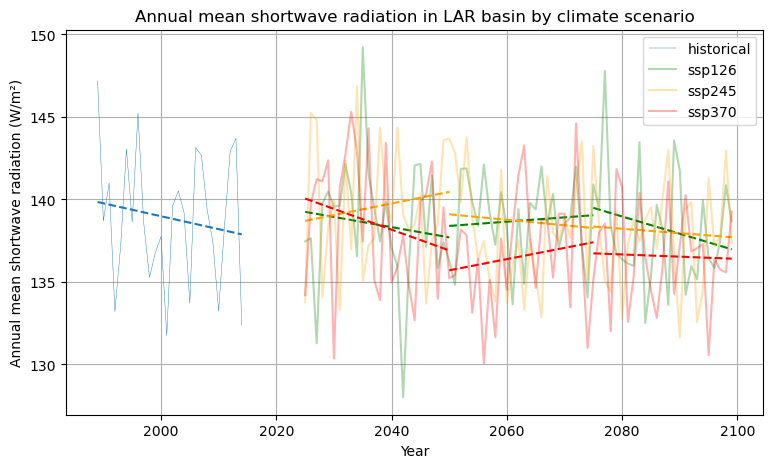

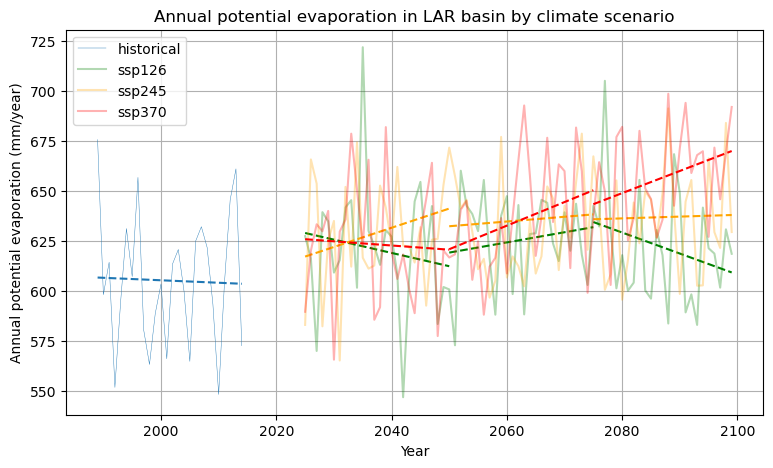

In [34]:
# Run function to display plots for each var_name
for var_name in ["pr", "tas", "rsds", "evspsblpot"]:
    plot_annual_forcing_variable(annual_table, var_name)

In [35]:
def plot_annual_forcing_variable_fulltrend(annual_forcing_table, var_name):

    # Combine historical and scenarios
    annual_forcing_table_all = pd.concat([annual_hist_table, annual_forcing_table],ignore_index=True)
    data = annual_forcing_table_all[annual_forcing_table_all["variable"] == var_name]
    
    plt.figure(figsize=(9, 5))
    
    # Loop through scenarios
    for scenario in scenarios_new:

        # Extract one scenario and colour 
        scenario_data = data[data["scenario"] == scenario]
        colour = colours[scenario]

        # # Plot historical 
        # if scenario == "historical":
            
        # Plot yearly average 
        plt.plot(scenario_data["year"],scenario_data["value"],color=colour,linewidth=0.3,label=scenario)

        x = scenario_data["year"].values
        y = scenario_data["value"].values

        # Polyfit method for making trendline function
        slope, intercept = np.polyfit(x, y, 1)
        trend = slope * x + intercept

        # Plot trendline
        plt.plot(x,trend,linestyle="--",color=colour)

        # # Plot other scenarios
        # else:

        #     # Plot yearly average
        #     plt.plot(scenario_data["year"],scenario_data["value"],alpha=0.3,color=colour,label=scenario)

        # # Look at each 25 year period
        # for i in range(len(periods[0])):

        #     # Define period range
        #     start_year = periods[0][i]
        #     end_year = periods[1][i]

        #     # Adjust data to fit period range
        #     period_data = scenario_data[
        #     (scenario_data["year"] >= start_year) & 
        #     (scenario_data["year"] <= end_year)]

        #     # Plot trend line over each 25 year period
        #     if len(period_data) > 1:

        #         x = period_data["year"].values
        #         y = period_data["value"].values

        #         # Polyfit method for making trendline function
        #         slope, intercept = np.polyfit(x, y, 1)
        #         trend = slope * x + intercept

        #         # Plot trendline
        #         plt.plot(x,trend,linestyle="--",color=colour)

    # Define titles and labels based on var_name
    if var_name == "pr":
        ylabel = "Annual precipitation (mm/year)"
        title = "Annual precipitation in LAR basin by climate scenario"

    elif var_name == "evspsblpot":
        ylabel = "Annual potential evaporation (mm/year)"
        title = "Annual potential evaporation in LAR basin by climate scenario"

    elif var_name == "tas":
        ylabel = "Annual mean temperature increase (°C)"
        title = "Annual mean temperature in LAR basin by climate scenario"

    elif var_name == "rsds":
        ylabel = "Annual mean shortwave radiation (W/m²)"
        title = "Annual mean shortwave radiation in LAR basin by climate scenario"

    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

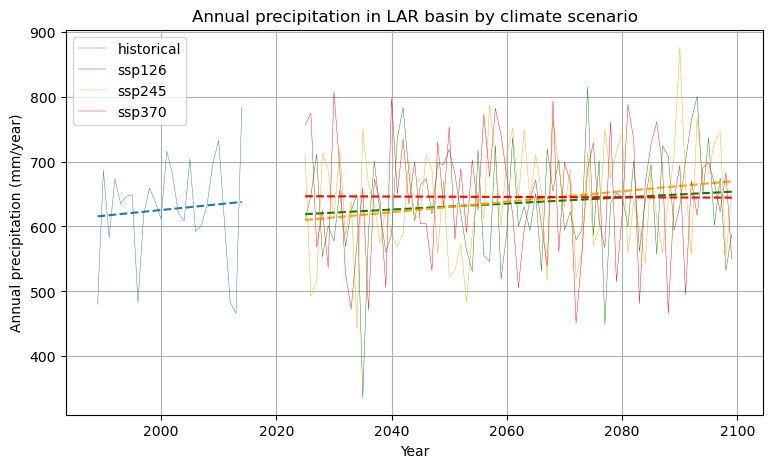

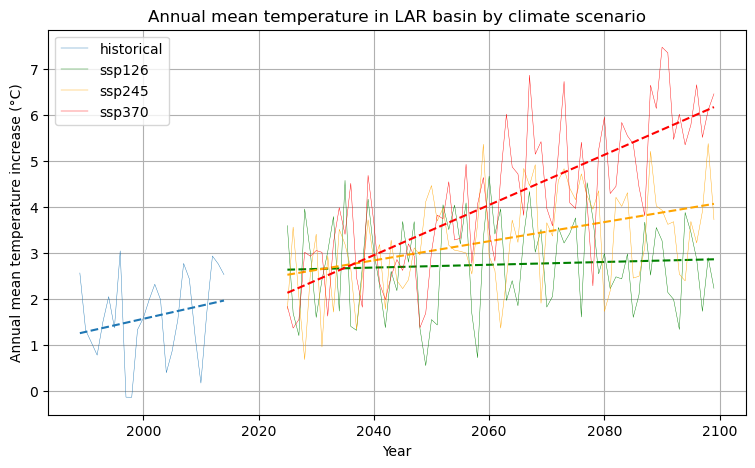

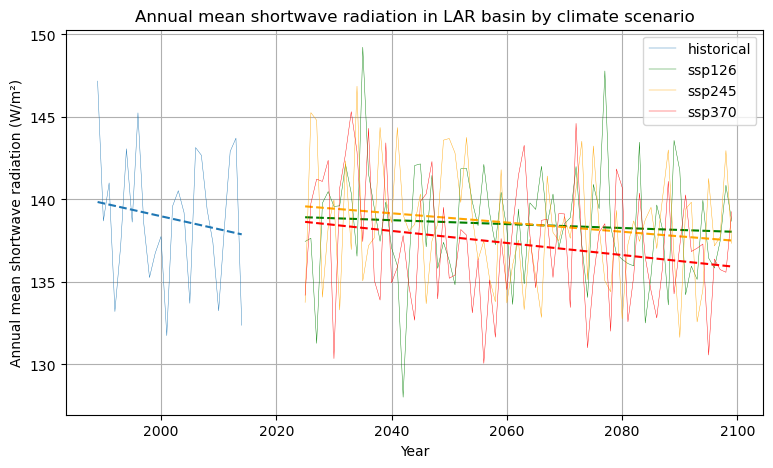

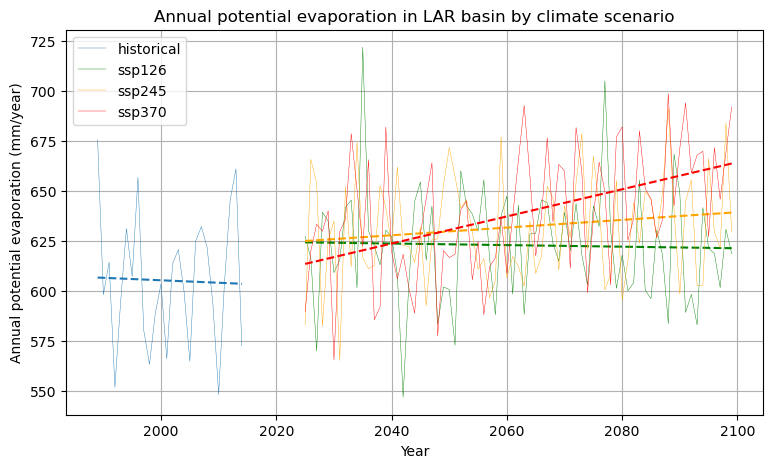

In [36]:
# Run function to display plots for each var_name
for var_name in ["pr", "tas", "rsds", "evspsblpot"]:
    plot_annual_forcing_variable_fulltrend(annual_table, var_name)

## 7. Algorithm checker

This will be split into two sections: Defining start of navigable season (river ice break up) & end of navigable season (river freeze up). Each section includes the function coding AND data display.

##### 7.1 Freshet start date
##### 7.2 River freeze up

### 7.1 River break up 

##### The first step is to create a function to calculate the future break up dates.
##### The second step is to create a function to plot a bar chart. The same chart can be called and used for 7.2 for river freeze up. 

In [37]:
q_critical = 500

def find_breakup_dates(projection_data, start_year_hist, end_year_hist,start_year_fut, end_year_fut):

    freshet_start_dates = []

    for scenario in scenarios_new:

        # Select years and discharge data depending on scenario
        if scenario == "historical":

            start_year_use = start_year_hist
            end_year_use = end_year_hist

            discharge_data = q_obs.copy()
            discharge_data["Year"] = discharge_data["Date"].dt.year
            
            discharge_col = "discharge_m3s"

        else:

            start_year_use = start_year_fut
            end_year_use = end_year_fut

            discharge_data_list = []

            for i in range(len(periods[0])):

                start_year = periods[0][i]
                end_year = periods[1][i]

                key = f"{scenario}_{start_year}_{end_year}"

                period_data = projection_data[key]["ensemble"].copy()

                period_data["Date"] = pd.to_datetime(period_data.index)
                period_data["Year"] = period_data["Date"].dt.year

                discharge_data_list.append(period_data)

            discharge_data = pd.concat(discharge_data_list)
            discharge_data = discharge_data.drop_duplicates(subset="Date", keep="first")
            discharge_data = discharge_data.sort_values("Date")

            discharge_col = "Mean"

        # Loop through every year
        for year in range(start_year_use, end_year_use + 1):

            # Select data after March 1
            season_data = discharge_data[
                (discharge_data["Year"] == year) &
                (discharge_data["Date"] >= pd.to_datetime(f"{year}-03-01"))]

            # Identify first day where q > q_critical
            above_critical = season_data[
                season_data[discharge_col] > q_critical]

            if len(above_critical) > 0:

                first_day = above_critical.iloc[0]

                freshet_start_dates.append({
                    "scenario": scenario,
                    "year": year,
                    "freshet_start_date": first_day["Date"],
                    "discharge_m3s": first_day[discharge_col]})

    freshet_start_dates = pd.DataFrame(freshet_start_dates)

    return freshet_start_dates

In [38]:
breakup_start_dates = find_breakup_dates(
    projection_data=projection_data,
    start_year_hist=2000,
    end_year_hist=2025,
    start_year_fut=2025,
    end_year_fut=2099)

breakup_start_dates

,scenario,year,freshet_start_date,discharge_m3s
0,historical,2000,2000-05-17,561.000000
1,historical,2001,2001-05-04,510.000000
2,historical,2002,2002-05-07,600.000000
3,historical,2003,2003-04-26,600.000000
4,historical,2004,2004-04-14,533.000000
...,...,...,...,...
246,ssp370,2095,2095-03-06,573.481886
247,ssp370,2096,2096-03-23,520.442698
248,ssp370,2097,2097-04-19,511.132103
249,ssp370,2098,2098-03-16,601.581833


In [39]:
def plot_freshet_barchart_10day(freshet_dates, title, colname):

    data = freshet_dates.copy()

    # Convert freshet start date to day-of-year
    data["doy"] = data[colname].dt.dayofyear

    # Define 10-day bins
    min_doy = int(data["doy"].min())
    max_doy = int(data["doy"].max())

    bins = np.arange(min_doy, max_doy + 10, 10)

    data["date_bin"] = pd.cut(data["doy"], bins=bins, right=False)

    # Count number of freshet dates per scenario per bin
    count_table = (data.groupby(["date_bin", "scenario"]).size().reset_index(name="count"))

    # Create readable labels for bins
    bin_labels = []

    for interval in count_table["date_bin"].cat.categories:
        start_date = pd.Timestamp("2000-01-01") + pd.Timedelta(days=int(interval.left) - 1)
        end_date   = pd.Timestamp("2000-01-01") + pd.Timedelta(days=int(interval.right) - 2)

        label = f"{start_date.strftime('%b %d')}-{end_date.strftime('%b %d')}"
        bin_labels.append(label)

    label_map = dict(zip(count_table["date_bin"].cat.categories, bin_labels))
    
    count_table["date_bin_label"] = count_table["date_bin"].map(label_map)

    # Pivot for plotting
    plot_table = count_table.pivot_table(index="date_bin_label", columns="scenario", values="count", fill_value=0)

    # Remove bins where all scenarios have zero observations
    plot_table = plot_table.loc[plot_table.sum(axis=1) > 0]

    # Plot
    plot_table.plot(kind="bar", figsize=(10, 5), color=[colours[scenario] for scenario in plot_table.columns])

    plt.xlabel(f"{title} date range")
    plt.ylabel("Number of years")
    plt.title(f"Distribution of {title} dates by climate scenario")
    plt.grid(axis="y")
    plt.legend(title="Scenario")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(range(0, int(plot_table.to_numpy().max()) + 1, 3))

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_126637/3610468776.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_126637/3610468776.py:34: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


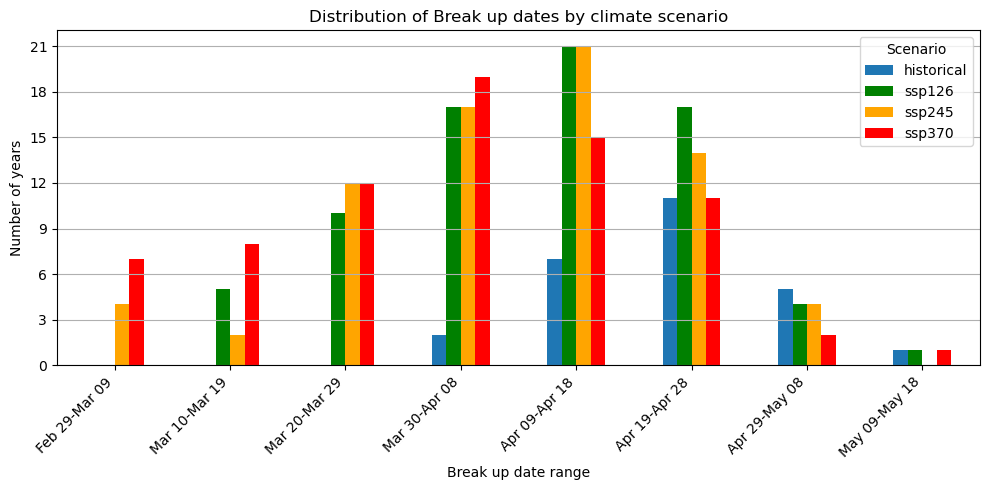

In [40]:
plot_freshet_barchart_10day(freshet_dates=breakup_start_dates, colname="freshet_start_date", title="Break up")

### 7.2 River freeze up

The first step is to find the freeze dates using the def function below. After the previously made barchart function can be called.

In [41]:
AFDD_critical = 30

def find_freezeup_dates(forcing_data, start_year_fut, end_year_fut, start_year_hist, end_year_hist):

    AFDD_critical_dates = []

    for scenario in scenarios_new:

        # Extract temperature above surface (tas) data
        temp_data = forcing_data_all[scenario]["tas"]

        # Convert into df to make life easier
        temp_data = pd.DataFrame({"Date": temp_data.index, "Temp": temp_data.values})

        # Conver to datetime
        temp_data["Date"] = pd.to_datetime(temp_data["Date"])

        # Assign year to each data point
        temp_data["Year"] = temp_data["Date"].dt.year

        if scenario == "historical":
            
            start_year_use = start_year_hist
            end_year_use = end_year_hist

        else:

            start_year_use = start_year_fut
            end_year_use = end_year_fut
    
        # Loop through every year
        for year in range(start_year_use, end_year_use + 1):

            # Start counting from October 1 to eliminate anomalies
            year_data = temp_data[
                (temp_data["Year"] == year) &
                (temp_data["Date"] >= pd.to_datetime(f"{year}-10-01"))]

            # Set 0 as starting point for counting cumulative
            AFDD = 0

            # Loop through all data points in a year
            for i in range(len(year_data)):

                temp = year_data.iloc[i]["Temp"]
                date = year_data.iloc[i]["Date"]

                # Cumulative AFDD
                if temp < 0:
                    AFDD += -temp

                # Append when AFDD is critical
                if AFDD >= AFDD_critical:

                    AFDD_critical_dates.append({
                        "scenario": scenario,
                        "year": year,
                        "AFDD_critical_date": date,
                        "AFDD": AFDD,
                        "Temp": temp})
                    
                    break

    AFDD_critical_dates = pd.DataFrame(AFDD_critical_dates)

    return AFDD_critical_dates

In [42]:
freezeup_dates_future = find_freezeup_dates(
    forcing_data=forcing_data,
    start_year_fut=2025,
    end_year_fut=2099,
    start_year_hist=1989,
    end_year_hist=2014)

freezeup_dates_future

,scenario,year,AFDD_critical_date,AFDD,Temp
0,historical,1989,1989-11-01,32.489258,-2.629700
1,historical,1990,1990-11-12,30.216248,-6.528046
2,historical,1991,1991-11-15,31.900940,-2.974640
3,historical,1992,1992-11-01,36.211761,-10.461182
4,historical,1993,1993-10-09,30.085388,-0.323120
...,...,...,...,...,...
246,ssp370,2095,2095-11-15,32.214935,-7.631531
247,ssp370,2096,2096-11-25,34.426178,-6.217194
248,ssp370,2097,2097-11-19,35.140442,-7.922821
249,ssp370,2098,2098-11-14,31.264648,-9.818970


The second step is to visualise this data (below)

/tmp/ipykernel_126637/3610468776.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_126637/3610468776.py:34: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


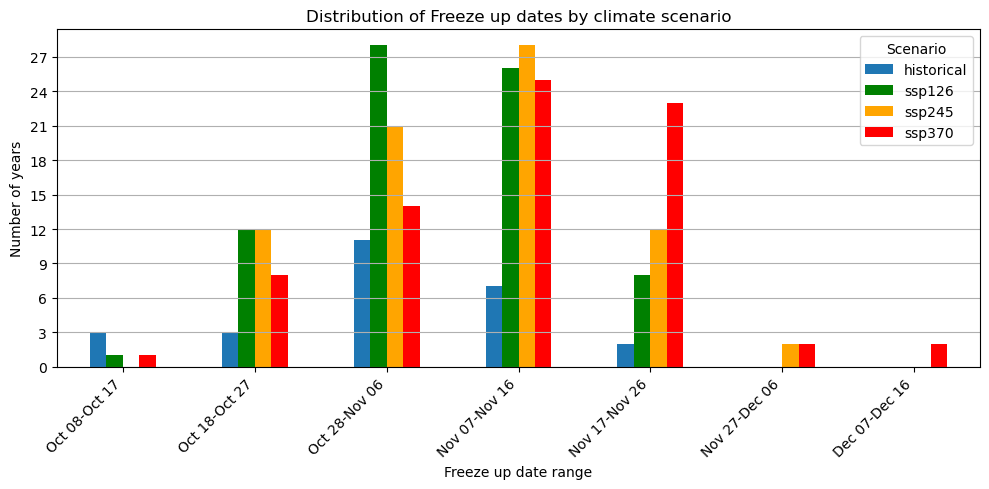

In [43]:
# Call barchart function from 7.1

plot_freshet_barchart_10day(freshet_dates=freezeup_dates_future, colname="AFDD_critical_date", title="Freeze up")